In [ ]:
import os
import sys
import types
import glob
import random
import yaml

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.insert(0, "..")
from models.beta_vae import BetaVAE
from data_utils import build_face_dataloaders

## Config

In [ ]:
CONFIG_PATH = "config/betavae_full_cfd.yaml"   # relative to repo root
CKPT_PATH   = None   # None → load latest checkpoint from experiment output dir
N_SAMPLES   = 8      # images to show in reconstruction grid
SEED        = 42

random.seed(SEED)
torch.manual_seed(SEED)

## Load model & checkpoint

In [ ]:
REPO_ROOT = os.path.abspath("..")

with open(os.path.join(REPO_ROOT, CONFIG_PATH)) as f:
    cfg = types.SimpleNamespace(**yaml.safe_load(f))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BetaVAE(
    input_channels=cfg.input_channels,
    input_height=cfg.input_height,
    input_width=cfg.input_width,
    latent_dim=cfg.latent_dim,
    hidden_dim=cfg.hidden_dim,
    beta=cfg.beta,
    device=device,
)

if CKPT_PATH is None:
    ckpt_dir = os.path.join(REPO_ROOT, cfg.output_dir, "checkpoints")
    ckpts = glob.glob(os.path.join(ckpt_dir, "*.pt"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")
    CKPT_PATH = max(ckpts, key=lambda p: int(p.rsplit("step", 1)[-1].replace(".pt", "")))

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded: {CKPT_PATH}  (step {ckpt['step']})")

## Reconstructions

In [ ]:
_, val_dl = build_face_dataloaders(
    cfd_dir=os.path.join(REPO_ROOT, cfg.cfd_dir) if not os.path.isabs(cfg.cfd_dir) else cfg.cfd_dir,
    expressions=cfg.expressions,
    image_size=(cfg.input_height, cfg.input_width),
    train_split=cfg.train_split,
    batch_size=cfg.batch_size,
)
# Collect all val images into one tensor for easy random sampling
all_images = torch.cat([b for b in val_dl], dim=0)

indices = random.sample(range(len(all_images)), min(N_SAMPLES, len(all_images)))
originals = all_images[indices].to(device)

with torch.no_grad():
    x_recon, _, _ = model(originals)
    x_recon = torch.sigmoid(x_recon).cpu()

originals_cpu = originals.cpu()
n = len(indices)

fig, axes = plt.subplots(2, n, figsize=(n * 2, 5))
fig.suptitle("Top: original  |  Bottom: beta-VAE reconstruction", fontsize=11)
for i in range(n):
    axes[0, i].imshow(originals_cpu[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[1, i].imshow(x_recon[i].permute(1, 2, 0))
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## Latent activation distributions

Pass every image in the dataset through the encoder and collect the posterior mean μ for each latent dimension.

In [ ]:
all_mu = []
with torch.no_grad():
    for batch in val_dl:
        batch = batch.to(device)
        _, mu, _ = model(batch)
        all_mu.append(mu.cpu())

all_mu = torch.cat(all_mu, dim=0).numpy()  # [N, latent_dim]
print(f"Collected μ for {all_mu.shape[0]} images across {all_mu.shape[1]} latent dimensions")

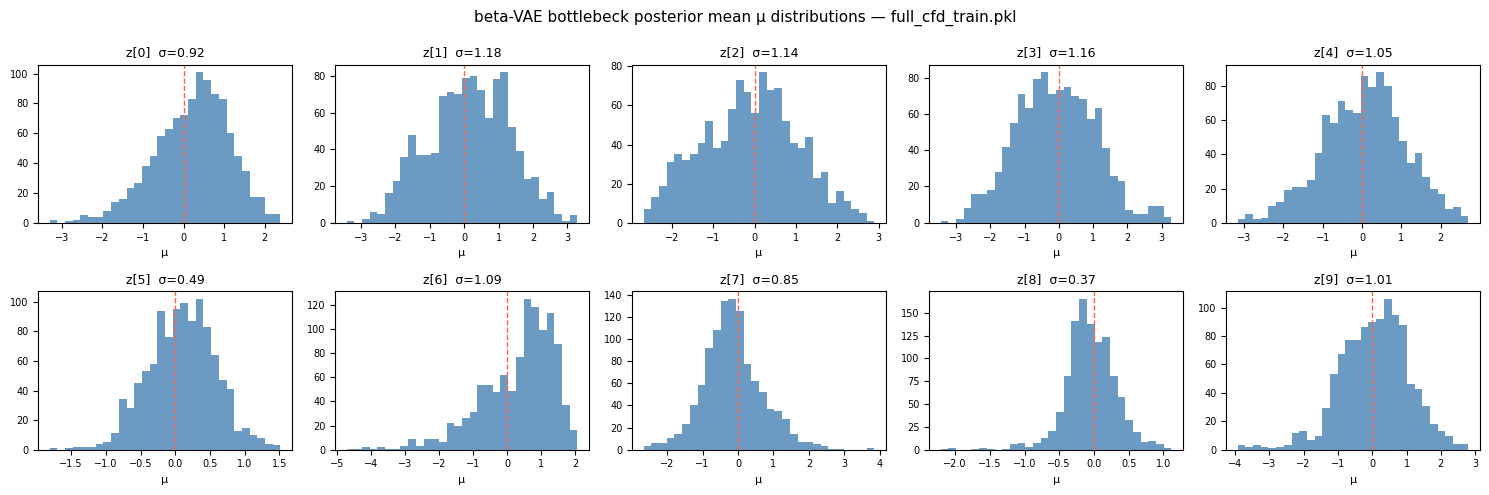

In [12]:
latent_dim = all_mu.shape[1]
ncols = min(5, latent_dim)
nrows = (latent_dim + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = np.array(axes).flatten()

for i in range(latent_dim):
    axes[i].hist(all_mu[:, i], bins=30, color="steelblue", alpha=0.8, edgecolor="none")
    axes[i].axvline(0, color="tomato", linewidth=1, linestyle="--")
    axes[i].set_title(f"z[{i}]  σ={all_mu[:, i].std():.2f}", fontsize=9)
    axes[i].set_xlabel("μ", fontsize=8)
    axes[i].tick_params(labelsize=7)

for i in range(latent_dim, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f"beta-VAE bottlebeck posterior mean μ distributions — {os.path.basename(DATASET_PATH)}", fontsize=11)
plt.tight_layout()
plt.show()